Machine Learning Project

Importing Modules

In [1]:
%pip install pandas numpy matplotlib scikit-learn

  Using cached matplotlib-3.10.9-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
Using cached matplotlib-3.10.9-cp313-cp313-win_amd64.whl (8.2 MB)
Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl (8.0 MB)
Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl (226 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler

Matplotlib is building the font cache; this may take a moment.


Loading Dataset

In [3]:
df = pd.read_csv('water_potability.csv')
print(df.shape)
print(df.isnull().sum())
df.head()

(3276, 10)
ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [ ]:
df_clean = df.copy()
df_clean.fillna(df_clean.median(), inplace=True)
print(df_clean.isnull().sum().sum()) 

0


In [5]:
feature_cols = [c for c in df_clean.columns if c != 'Potability']

# D1 - original (after imputation)
D1 = df_clean.copy()

# D2 - MinMax scaled
D2 = D1.copy()
D2[feature_cols] = MinMaxScaler().fit_transform(D1[feature_cols])

# D3 - Standard scaled
D3 = D1.copy()
D3[feature_cols] = StandardScaler().fit_transform(D1[feature_cols])

print('D1:', D1.shape)
print('D2:', D2.shape)
print('D3:', D3.shape)

D1: (3276, 10)
D2: (3276, 10)
D3: (3276, 10)


In [6]:
#Checking the Scaling
# Check D1 - original values
print("D1 (original):")
print(D1[feature_cols].describe().loc[['min', 'max', 'mean']].round(2))

# Check D2 - should be between 0 and 1
print("\nD2 (MinMax):")
print(D2[feature_cols].describe().loc[['min', 'max', 'mean']].round(2))

# Check D3 - should have mean ~0
print("\nD3 (Standard):")
print(D3[feature_cols].describe().loc[['min', 'max', 'mean']].round(2))

D1 (original):
         ph  Hardness    Solids  Chloramines  Sulfate  Conductivity  \
min    0.00     47.43    320.94         0.35   129.00        181.48   
max   14.00    323.12  61227.20        13.13   481.03        753.34   
mean   7.07    196.37  22014.09         7.12   333.61        426.21   

      Organic_carbon  Trihalomethanes  Turbidity  
min             2.20             0.74       1.45  
max            28.30           124.00       6.74  
mean           14.28            66.41       3.97  

D2 (MinMax):
        ph  Hardness  Solids  Chloramines  Sulfate  Conductivity  \
min   0.00      0.00    0.00         0.00     0.00          0.00   
max   1.00      1.00    1.00         1.00     1.00          1.00   
mean  0.51      0.54    0.36         0.53     0.58          0.43   

      Organic_carbon  Trihalomethanes  Turbidity  
min             0.00             0.00       0.00  
max             1.00             1.00       1.00  
mean            0.46             0.53       0.48  

D3 (

Classification

In [7]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

# Helper function to evaluate any model
def evaluate(clf, X_train, X_test, y_train, y_test, label):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    print(f'=== {label} ===')
    print(f'Accuracy: {acc:.4f}')
    print(classification_report(y_test, y_pred, target_names=['Not Potable', 'Potable']))
    ConfusionMatrixDisplay(cm, display_labels=['Not Potable', 'Potable']).plot(cmap='Blues')
    plt.title(label)
    plt.show()
    return acc, cm

In [9]:
#Train/Test Splits
def split(D):
    X = D[feature_cols]
    y = D['Potability']
    return train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X1_tr, X1_te, y1_tr, y1_te = split(D1)
X2_tr, X2_te, y2_tr, y2_te = split(D2)
X3_tr, X3_te, y3_tr, y3_te = split(D3)

print('Train size:', len(X1_tr), '| Test size:', len(X1_te))

Train size: 2620 | Test size: 656


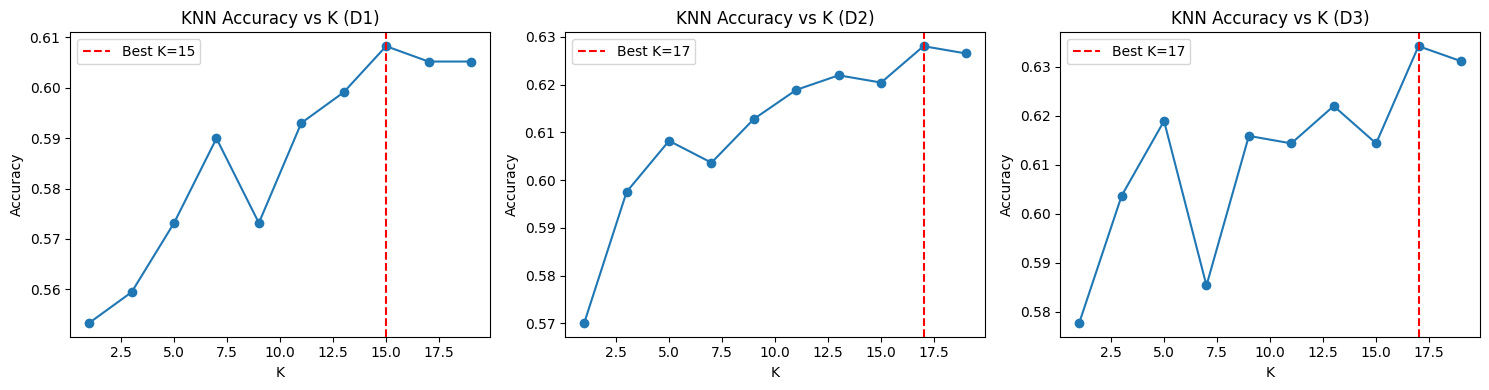

Best K per dataset:
  D1: K=15
  D2: K=17
  D3: K=17


In [19]:
#Finding the best K
datasets = {
    'D1': (X1_tr, X1_te, y1_tr, y1_te),
    'D2': (X2_tr, X2_te, y2_tr, y2_te),
    'D3': (X3_tr, X3_te, y3_tr, y3_te),
}

k_range = range(1, 20, 2)  # odd numbers only
best_ks = {}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, (X_tr, X_te, y_tr, y_te)) in zip(axes, datasets.items()):
    accuracies = []
    for k in k_range:
        knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
        knn.fit(X_tr, y_tr)
        accuracies.append(accuracy_score(y_te, knn.predict(X_te)))
    
    best_k = k_range[accuracies.index(max(accuracies))]
    best_ks[name] = best_k
    
    ax.plot(k_range, accuracies, marker='o')
    ax.set_title(f'KNN Accuracy vs K ({name})')
    ax.set_xlabel('K')
    ax.set_ylabel('Accuracy')
    ax.axvline(best_k, color='red', linestyle='--', label=f'Best K={best_k}')
    ax.legend()

plt.tight_layout()
plt.show()

print('Best K per dataset:')
for name, k in best_ks.items():
    print(f'  {name}: K={k}')

=== KNN — D1 (Original) | K=15 ===
Accuracy: 0.6082
              precision    recall  f1-score   support

 Not Potable       0.63      0.87      0.73       400
     Potable       0.50      0.20      0.28       256

    accuracy                           0.61       656
   macro avg       0.56      0.53      0.51       656
weighted avg       0.58      0.61      0.56       656



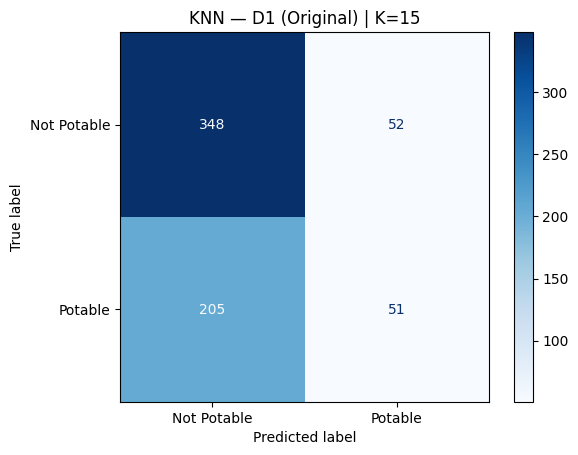

In [20]:
# KNN on D1
acc_d1_knn, cm_d1_knn = evaluate(
    KNeighborsClassifier(n_neighbors=best_ks['D1'], metric='euclidean'),
    X1_tr, X1_te, y1_tr, y1_te,
    f"KNN — D1 (Original) | K={best_ks['D1']}"
)

=== KNN — D2 (MinMax) | K=17 ===
Accuracy: 0.6280
              precision    recall  f1-score   support

 Not Potable       0.64      0.90      0.75       400
     Potable       0.56      0.21      0.31       256

    accuracy                           0.63       656
   macro avg       0.60      0.55      0.53       656
weighted avg       0.61      0.63      0.57       656



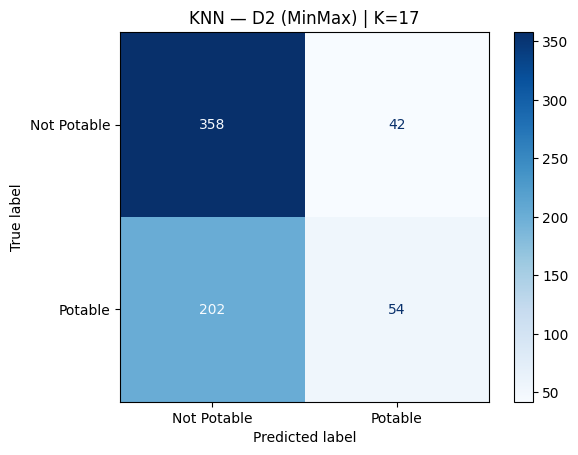

In [21]:
# KNN on D2
acc_d2_knn, cm_d2_knn = evaluate(
    KNeighborsClassifier(n_neighbors=best_ks['D2'], metric='euclidean'),
    X2_tr, X2_te, y2_tr, y2_te,
    f"KNN — D2 (MinMax) | K={best_ks['D2']}"
)

=== KNN — D3 (Standard) | K=17 ===
Accuracy: 0.6341
              precision    recall  f1-score   support

 Not Potable       0.65      0.88      0.75       400
     Potable       0.57      0.25      0.34       256

    accuracy                           0.63       656
   macro avg       0.61      0.56      0.55       656
weighted avg       0.62      0.63      0.59       656



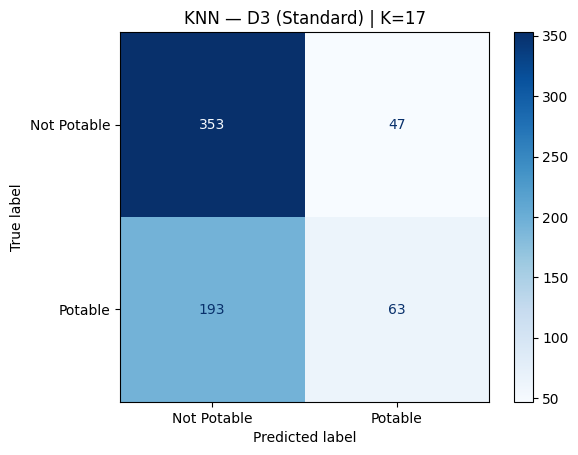

In [22]:
# KNN on D3
acc_d3_knn, cm_d3_knn = evaluate(
    KNeighborsClassifier(n_neighbors=best_ks['D3'], metric='euclidean'),
    X3_tr, X3_te, y3_tr, y3_te,
    f"KNN — D3 (Standard) | K={best_ks['D3']}"
)

=== KNN — D1 (Original) ===
Accuracy: 0.5732
              precision    recall  f1-score   support

 Not Potable       0.63      0.74      0.68       400
     Potable       0.43      0.31      0.36       256

    accuracy                           0.57       656
   macro avg       0.53      0.53      0.52       656
weighted avg       0.55      0.57      0.56       656



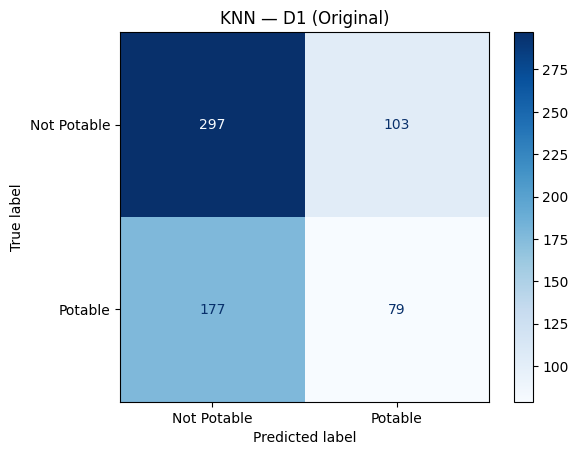

In [13]:
#KNN on D1
acc_d1_knn, cm_d1_knn = evaluate(
    KNeighborsClassifier(n_neighbors=5, metric='euclidean'),
    X1_tr, X1_te, y1_tr, y1_te,
    'KNN — D1 (Original)'
)

=== KNN — D2 (MinMax) ===
Accuracy: 0.6082
              precision    recall  f1-score   support

 Not Potable       0.64      0.81      0.72       400
     Potable       0.50      0.29      0.37       256

    accuracy                           0.61       656
   macro avg       0.57      0.55      0.54       656
weighted avg       0.58      0.61      0.58       656



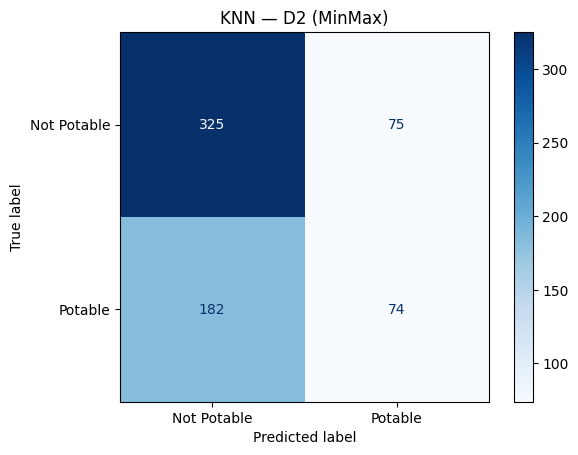

In [14]:
#KNN on D2
acc_d2_knn, cm_d2_knn = evaluate(
    KNeighborsClassifier(n_neighbors=5, metric='euclidean'),
    X2_tr, X2_te, y2_tr, y2_te,
    'KNN — D2 (MinMax)'
)

=== KNN — D3 (Standard) ===
Accuracy: 0.6189
              precision    recall  f1-score   support

 Not Potable       0.65      0.81      0.72       400
     Potable       0.52      0.33      0.40       256

    accuracy                           0.62       656
   macro avg       0.59      0.57      0.56       656
weighted avg       0.60      0.62      0.60       656



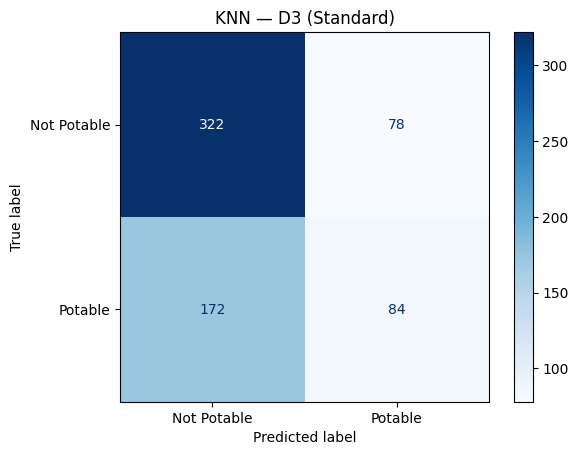

In [15]:
#KNN on D3
acc_d3_knn, cm_d3_knn = evaluate(
    KNeighborsClassifier(n_neighbors=5, metric='euclidean'),
    X3_tr, X3_te, y3_tr, y3_te,
    'KNN — D3 (Standard)'
)

In [25]:
#Summary Table
summary = pd.DataFrame({
    'Dataset':    ['D1', 'D2', 'D3', 'D1', 'D2', 'D3'],
    'Classifier': ['Decision Tree']*3 + ['KNN']*3,
    'Accuracy':   [acc_d1_dt, acc_d2_dt, acc_d3_dt,
                   acc_d1_knn, acc_d2_knn, acc_d3_knn]
})
summary['Accuracy'] = summary['Accuracy'].round(4)
summary

,Dataset,Classifier,Accuracy
0,D1,Decision Tree,0.5671
1,D2,Decision Tree,0.5671
2,D3,Decision Tree,0.5671
3,D1,KNN,0.6082
4,D2,KNN,0.6280
5,D3,KNN,0.6341
